# ResNet 与残差连接

这个 notebook 展示两条学习路径：
1. **迁移学习**：使用 torchvision 预训练的 ResNet50，冻结特征层后微调分类头。
2. **从零实现**：手写残差块，理解 ResNet 为什么能训练得更深。

## 学习目标
- 理解残差连接（skip connection）如何缓解深层网络的梯度消失。
- 掌握冻结特征提取层与全量微调的区别和适用场景。
- 学会将 ResNet 应用于 10 Monkeys 和 CIFAR-10 分类任务。

## 导入模型与数据工具

引入 `resnet50`、图像变换、DataLoader 和训练所需工具。预训练模型来自 torchvision，已在 ImageNet 上学过通用视觉特征，可直接迁移。

In [2]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, ConvertImageDtype
from torch import nn
from torchvision.models import resnet50
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
import gc
import sys

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 准备 10 Monkeys 数据集

沿用 `ImageFolder` 目录读取方式（详见 `10monkeys.ipynb`）。图片统一缩放至 224×224 并归一化，以匹配 ResNet 的输入要求。

In [6]:
DATA_DIR = Path('../data/10monkeys/archive')
IMG_SIZE = (224, 224)


class MonkeyDataset(datasets.ImageFolder):
    def __init__(self, mode, transform=None):

        root = DATA_DIR / "training" if mode == 'train' else DATA_DIR / "validation"

        super().__init__(root=root, transform=transform)
        self.targets = [_[1] for _ in self.samples]

# 计算数据的 mean 和 std


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    MonkeyDataset(mode='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))

transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std),
    ConvertImageDtype(torch.float32)
])

train_ds = MonkeyDataset(mode='train', transform=transform)
val_ds = MonkeyDataset(mode='validation', transform=transform)

Computing mean/std: 100%|██████████| 18/18 [00:13<00:00,  1.33it/s]


## DataLoader 配置

迁移学习同样按 batch 训练。训练集打乱，验证集保持顺序。`num_workers=0` 在 Windows 或 notebook 环境中更稳定。

In [7]:
batch_size = 128
num_workers = 0
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

## 迁移学习：冻结特征层

这版 `ResNet50` 加载 ImageNet 预训练权重，替换最后的全连接分类头（`fc`），并**冻结所有特征层参数**。

- 仅训练最后的分类头（约 2 万参数）。
- 优点：训练快、过拟合风险低、小数据集也能训练。
- 适用场景：目标任务与 ImageNet 相似、训练数据较少。

In [18]:
class ResNet50(nn.Module):
    def __init__(self, num_classes: int = 10, frozen: bool = True):
        super().__init__()
        self.model = resnet50(weights='IMAGENET1K_V2')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False

    def forward(self, x):
        return self.model(x)


print('冻结参数', sum(p.numel() for p in ResNet50().parameters()))
print('未冻结参数', sum(p.numel()
      for p in ResNet50().parameters() if p.requires_grad))

冻结参数 23528522
未冻结参数 0


## 迁移学习：全量微调

微调会解冻更多层（或全部层），让预训练参数也参与更新。相比仅训练分类头：
- 效果通常更好，因为特征提取层也能适配新任务。
- 需要更小的学习率（避免破坏预训练知识）。
- 需要更谨慎的训练轮数（大模型容易过拟合）。

In [19]:
# 微调大模型
class ResNet50(nn.Module):
    def __init__(self, num_classes: int = 10, frozen: bool = True):
        super().__init__()
        self.model = resnet50(weights='IMAGENET1K_V2')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False
            # 只训练最后一层
            for param in self.model.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.model(x)


print('冻结参数', sum(p.numel() for p in ResNet50().parameters()))
print('未冻结参数', sum(p.numel()
      for p in ResNet50().parameters() if p.requires_grad))

冻结参数 23528522
未冻结参数 20490


## 训练 ResNet50

将模型、损失函数、优化器和学习率调度器交给 `TorchTrainer` 统一管理。训练时重点观察验证准确率是否同步提升——如果训练 loss 下降但验证准确率不升，说明过拟合。

Epoch 1/20 | train_loss=2.0786 | train_acc=0.4558 | train_balanced_acc=0.4544 | train_f1_macro=0.4574 | val_loss=1.8837 | val_acc=0.8199 | val_balanced_acc=0.8165 | val_f1_macro=0.8115 | lr=0.0010 | epoch_seconds=18.3162


Epoch 2/20 | train_loss=1.4928 | train_acc=0.9116 | train_balanced_acc=0.9101 | train_f1_macro=0.9102 | val_loss=1.3539 | val_acc=0.9596 | val_balanced_acc=0.9595 | val_f1_macro=0.9587 | lr=0.0010 | epoch_seconds=17.6385


Epoch 3/20 | train_loss=1.0713 | train_acc=0.9654 | train_balanced_acc=0.9649 | train_f1_macro=0.9651 | val_loss=0.9909 | val_acc=0.9632 | val_balanced_acc=0.9632 | val_f1_macro=0.9627 | lr=0.0010 | epoch_seconds=18.1973


Epoch 4/20 | train_loss=0.7729 | train_acc=0.9790 | train_balanced_acc=0.9789 | train_f1_macro=0.9789 | val_loss=0.7490 | val_acc=0.9669 | val_balanced_acc=0.9668 | val_f1_macro=0.9663 | lr=0.0010 | epoch_seconds=18.0771


Epoch 5/20 | train_loss=0.5835 | train_acc=0.9809 | train_balanced_acc=0.9807 | train_f1_macro=0.9808 | val_loss=0.5981 | val_acc=0.9743 | val_balanced_acc=0.9743 | val_f1_macro=0.9737 | lr=0.0010 | epoch_seconds=18.1824


...

Epoch 16/20 | train_loss=0.1169 | train_acc=0.9982 | train_balanced_acc=0.9982 | train_f1_macro=0.9982 | val_loss=0.1932 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.2012


Epoch 17/20 | train_loss=0.1059 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1833 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1991


Epoch 18/20 | train_loss=0.0987 | train_acc=0.9991 | train_balanced_acc=0.9991 | train_f1_macro=0.9991 | val_loss=0.1741 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1562


Epoch 19/20 | train_loss=0.0903 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1667 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1913


Epoch 20/20 | train_loss=0.0857 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1615 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1577


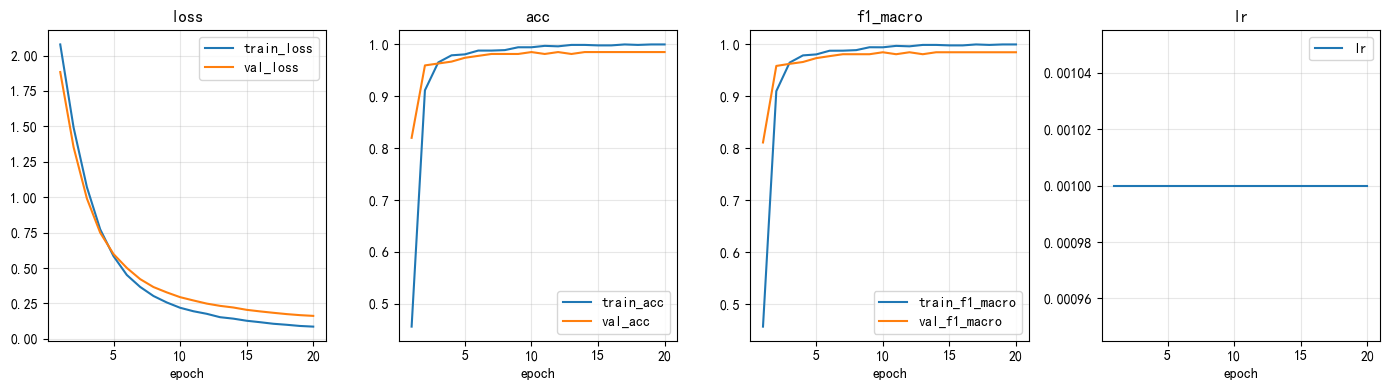

In [ ]:
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from base import TorchTrainer, ReduceLROnPlateau


model = ResNet50(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

trainer = TorchTrainer(
    model=model,
    criterion=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
    amp=True,
    checkpoint_dir="./checkpoints/resnet50_10monkeys"
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()

## 从零理解残差块

残差学习的核心公式：\[ $\text{output} = F(x) + x$ \]

网络不直接学习目标映射 $H(x)$，而是学习残差 $F(x) = H(x) - x$。跳跃连接让梯度可以绕过中间层直接传回：

- **前向**：信息有"快速通道"，即使中间层学不好，至少可以保留输入。
- **反向**：梯度可以通过跳跃连接直接传到浅层，缓解梯度消失。

残差块中 1×1 卷积的作用：当输入输出通道数不匹配或步长不为 1 时，对齐 shortcut 分支的维度。

In [3]:
# ResNet 的核心是残差块（Residual Block），它通过引入跳跃连接（skip connection）来缓解深层网络中的梯度消失问题。
# 残差块的基本思想是让网络学习一个残差函数，而不是直接学习输入到输出的映射。这使得网络更容易优化，并且能够训练更深的模型。

# 残差层 (Residual Layer) 是残差块中的一个组件，它包含两个卷积层和一个可选的 1x1 卷积层，用于调整输入和输出的维度。
# 残差层的结构如下：
class Residual(nn.Module):
    def __init__(self, input_channels, output_channels, use_1x1=False, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            input_channels, output_channels, kernel_size=3, padding=1, stride=stride)
        self.conv2 = nn.Conv2d(
            output_channels, output_channels, kernel_size=3, padding=1, stride=1)
        if use_1x1:
            self.conv_sc = nn.Conv2d(
                input_channels, output_channels, kernel_size=1, stride=stride)
        else:
            self.conv_sc = None
        self.bn1 = nn.BatchNorm2d(output_channels, eps=1e-5, momentum=0.9)
        self.bn2 = nn.BatchNorm2d(output_channels, eps=1e-5, momentum=0.9)
        self.relu = nn.ReLU()

    def forward(self, x):
        flow = self.relu(self.bn1(self.conv1(x)))
        flow = self.bn2(self.conv2(flow))
        if self.conv_sc is not None:
            x = self.conv_sc(x)
        return self.relu(flow + x)


# 残差块 (Residual Block) 是由多个残差层组成的模块，通常用于构建 ResNet 的不同阶段。
# 每个残差块可以包含一个或多个残差层，具体取决于网络的深度和设计。
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, num_residuals, first_block=False):
        super().__init__()
        self.model = nn.Sequential()

        self.model.append(
            Residual(
                input_channels, output_channels,
                use_1x1=not first_block, stride=1 if first_block else 2
            ))  # 负责通道翻倍

        for _ in range(1, num_residuals):
            self.model.append(
                Residual(output_channels, output_channels))  # 负责通道不变

    def forward(self, x):
        return self.model(x)


# 残差网络
class ResNet(nn.Module):
    def __init__(self, n=3, num_classes: int = 10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1),
            nn.BatchNorm2d(16, 1e-5, 0.9),
            nn.ReLU(),
            ResidualBlock(16, 16, 2 * n, True),
            ResidualBlock(16, 32, 2 * n),
            ResidualBlock(32, 64, 2 * n),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)


print("Total parameters:", sum(p.numel() for p in ResNet().parameters()))

Total parameters: 565386


In [4]:
def get_trainer():
    import sys
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    from base import TorchTrainer
    return TorchTrainer

## 迁移到 CIFAR-10 实验

后半部分将残差网络迁移到 CIFAR-10。重新导入数据增强和自定义 Dataset 所需模块，让这个实验可以独立阅读。

In [2]:
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize, ConvertImageDtype, RandomRotation, RandomHorizontalFlip
)
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import gc

import torch
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## CIFAR-10 数据准备

CIFAR-10 的数据读取方式与 `cifar10.ipynb` 一致。与 10 Monkeys 不同，CIFAR-10 的标签来自 CSV 而非文件夹名。先生成类别映射（名称 ↔ 索引），再构建 Dataset。

In [5]:
DATA_DIR = Path('../data/cifar-10')
train_labels = pd.read_csv(DATA_DIR / 'trainLabels.csv')
test_labels = pd.read_csv(DATA_DIR / 'sampleSubmission.csv')
train_folder = DATA_DIR / 'train'
test_folder = DATA_DIR / 'test'

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


def get_image_path(labels, folder):
    path_labels = []
    for index, row in labels.iterrows():
        image_id = row['id']
        image_label = row['label']
        image_path = folder / f"{image_id}.png"
        path_labels.append((image_path, image_label))
    return path_labels


train_image_paths = get_image_path(train_labels, train_folder)
test_image_paths = get_image_path(test_labels, test_folder)

ratio = 0.9
train_df = pd.DataFrame(
    train_image_paths[:int(len(train_image_paths) * ratio)],
    columns=['image_path', 'label'])
val_df = pd.DataFrame(
    train_image_paths[int(len(train_image_paths) * ratio):],
    columns=['image_path', 'label'])
test_df = pd.DataFrame(test_image_paths, columns=['image_path', 'label'])

## 自定义 Dataset

Dataset 实现与 `cifar10.ipynb` 中相同：根据索引定位图片 → 读取 → 应用 transform → 返回 `(image, label)`。训练模式使用随机增强，验证/测试使用确定性预处理。

In [6]:
class Cifar10Dataset(Dataset):
    df_map = {
        'train': train_df,
        'val': val_df,
        'test': test_df
    }

    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, model="train", transform=None):
        self.data = self.df_map[model]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, label = self.data.iloc[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.label_to_idx[label]
        return image, label


IMG_SIZE = 32


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    Cifar10Dataset(model='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))

print("mean=", mean, "std=", std)

# 图像增强可以增加训练数据的多样性，帮助模型更好地泛化，从而提高模型的性能和鲁棒性。
# 1. 随机旋转图像：通过随机旋转图像，可以模拟不同的拍摄角度和姿态，使模型更好地适应各种视角。
# 2. 随机水平翻转图像：通过随机水平翻转图像，可以模拟左右对称的物体，使模型更好地适应不同的方向和姿态。
# 3. 随机裁剪图像：通过随机裁剪图像，可以模拟不同的物体位置和大小，使模型更好地适应各种场景和物体尺寸。
# 4. 随机调整图像亮度、对比度和饱和度：通过随机调整图像的亮度、对比度和饱和度，可以模拟不同的光照条件和环境，使模型更好地适应各种光照变化。
# 5. 随机添加噪声：通过随机添加噪声，可以模拟不同的图像质量和干扰，使模型更好地适应各种图像质量和干扰情况。
transform_train = Compose([
    Resize(IMG_SIZE),
    # 随机旋转图像，旋转角度在-40到40度之间
    RandomRotation(40),
    # 随机水平翻转图像，翻转概率为0.5
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

transform_eval = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

Computing mean/std: 100%|██████████| 704/704 [00:15<00:00, 44.09it/s]

mean= [0.49154943227767944, 0.48212525248527527, 0.44642722606658936] std= [0.2024068385362625, 0.19950436055660248, 0.20095086097717285]


## DataLoader（CIFAR-10）

与之前流程一致：训练集打乱，验证/测试保持顺序。这套模式可以视为图像分类项目的标准骨架。

In [7]:
train_ds = Cifar10Dataset(model='train', transform=transform_train)
val_ds = Cifar10Dataset(model='val', transform=transform_eval)
test_ds = Cifar10Dataset(model='test', transform=transform_eval)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## 训练自定义 ResNet

用手写的残差网络训练 CIFAR-10。与预训练 ResNet50 相比：
- 更适合理解结构本身。
- 性能更依赖数据量、训练轮数和正则化策略。
- 参数更少（约 56 万 vs 2350 万），训练更快。

Epoch 1/20 | train_loss=1.5810 | train_acc=0.4180 | train_balanced_acc=0.4180 | train_f1_macro=0.4131 | val_loss=1.3297 | val_acc=0.5160 | val_balanced_acc=0.5151 | val_f1_macro=0.5062 | lr=0.0010 | epoch_seconds=31.5118


Epoch 2/20 | train_loss=1.2678 | train_acc=0.5410 | train_balanced_acc=0.5411 | train_f1_macro=0.5381 | val_loss=1.1387 | val_acc=0.5896 | val_balanced_acc=0.5892 | val_f1_macro=0.5804 | lr=0.0010 | epoch_seconds=31.3583


Epoch 3/20 | train_loss=1.1127 | train_acc=0.6013 | train_balanced_acc=0.6013 | train_f1_macro=0.5995 | val_loss=0.9963 | val_acc=0.6546 | val_balanced_acc=0.6523 | val_f1_macro=0.6453 | lr=0.0010 | epoch_seconds=31.3188


Epoch 4/20 | train_loss=1.0086 | train_acc=0.6419 | train_balanced_acc=0.6419 | train_f1_macro=0.6406 | val_loss=1.1224 | val_acc=0.6472 | val_balanced_acc=0.6443 | val_f1_macro=0.6447 | lr=0.0010 | epoch_seconds=37.8354


Epoch 5/20 | train_loss=0.9252 | train_acc=0.6742 | train_balanced_acc=0.6742 | train_f1_macro=0.6730 | val_loss=0.9772 | val_acc=0.6748 | val_balanced_acc=0.6768 | val_f1_macro=0.6748 | lr=0.0010 | epoch_seconds=33.6447


...

Epoch 16/20 | train_loss=0.5723 | train_acc=0.8011 | train_balanced_acc=0.8010 | train_f1_macro=0.8006 | val_loss=0.6634 | val_acc=0.7890 | val_balanced_acc=0.7913 | val_f1_macro=0.7868 | lr=0.0010 | epoch_seconds=30.7222


Epoch 17/20 | train_loss=0.5632 | train_acc=0.8046 | train_balanced_acc=0.8045 | train_f1_macro=0.8041 | val_loss=0.6646 | val_acc=0.7850 | val_balanced_acc=0.7840 | val_f1_macro=0.7804 | lr=0.0010 | epoch_seconds=30.7397


Epoch 18/20 | train_loss=0.5443 | train_acc=0.8078 | train_balanced_acc=0.8078 | train_f1_macro=0.8073 | val_loss=0.5965 | val_acc=0.7968 | val_balanced_acc=0.7971 | val_f1_macro=0.7963 | lr=0.0010 | epoch_seconds=30.4952


Epoch 19/20 | train_loss=0.5272 | train_acc=0.8168 | train_balanced_acc=0.8167 | train_f1_macro=0.8163 | val_loss=0.5299 | val_acc=0.8154 | val_balanced_acc=0.8157 | val_f1_macro=0.8143 | lr=0.0010 | epoch_seconds=30.4805


Epoch 20/20 | train_loss=0.5170 | train_acc=0.8175 | train_balanced_acc=0.8174 | train_f1_macro=0.8171 | val_loss=0.6368 | val_acc=0.7882 | val_balanced_acc=0.7881 | val_f1_macro=0.7898 | lr=0.0010 | epoch_seconds=30.4103


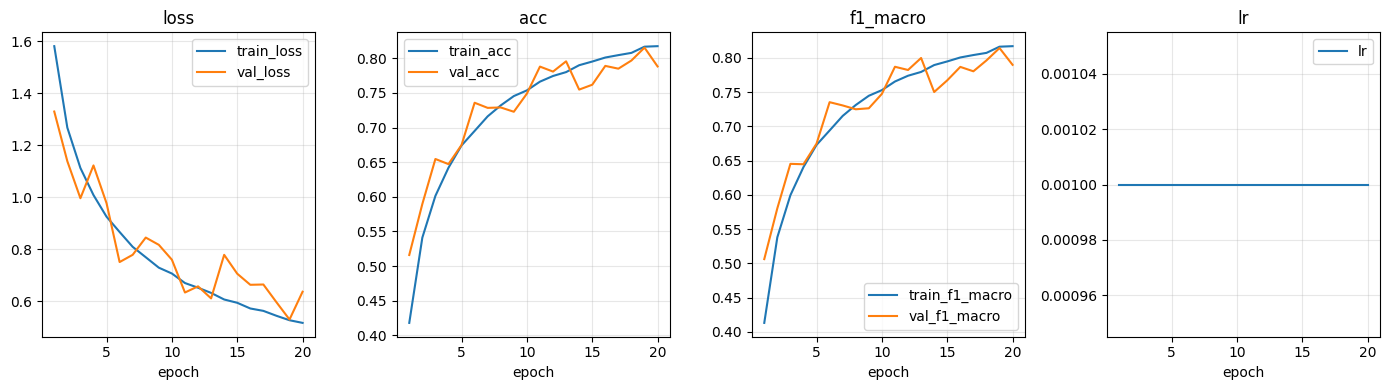

In [8]:
model = ResNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

trainer = get_trainer()(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()